In [2]:
from sklearn.metrics import classification_report, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
all_annotations = pd.read_csv("../../annotations/final_labels_rq2.csv", skiprows=0)  # first row is data

In [12]:
all_annotations

,Filename,Period,Date,Speech #,Paragraph #,Speaker,Role,Gender,Party,Interjector Party,...,partition,entropy,correct,merged_true,merged_pred,merged_correct,Unnamed: 0,prediction_changed,flagged_phaseIII,entropy_phaseIII
0,20_0002.xml,20,11.11.2021,3,7,Franziska Brantner,NaN,weiblich,GRUENE,SPD,...,unlabeled,0.023240,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20_0002.xml,20,11.11.2021,4,4,Till Mansmann,NaN,männlich,FDP,SPD,...,train,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20_0002.xml,20,11.11.2021,4,4,Till Mansmann,NaN,männlich,FDP,SPD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20_0002.xml,20,11.11.2021,4,5,Till Mansmann,NaN,männlich,FDP,FDP,...,unlabeled,1.427727,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20_0002.xml,20,11.11.2021,9,6,Reinhard Houben,NaN,männlich,FDP,GRUENE,...,train,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5778,20_0213.xml,20,13.03.2025,5,16,Johannes Vogel,NaN,männlich,FDP,GRUENE,...,unlabeled,0.678934,0.0,NaN,NaN,NaN,5757.0,False,True,0.827598
5779,20_0213.xml,20,13.03.2025,4,17,Christian Dürr,NaN,männlich,FDP,GRUENE,...,unlabeled,0.785907,0.0,NaN,NaN,NaN,5760.0,False,True,0.499374
5780,20_0213.xml,20,13.03.2025,15,4,Achim Post,NaN,männlich,SPD,FDP,...,unlabeled,0.418373,0.0,NaN,NaN,NaN,5764.0,False,True,0.354835
5781,20_0214.xml,20,18.03.2025,10,1,Franziska Brantner,NaN,weiblich,GRUENE,FDP,...,unlabeled,0.177086,0.0,NaN,NaN,NaN,5769.0,False,True,0.391014


### Inspect Samples Where Predictions Changed

In [13]:
prediction_changed = (
    all_annotations
      .iloc[1:]
      .query('partition == "unlabeled" and prediction_changed == True')
)

In [14]:
prediction_changed

,Filename,Period,Date,Speech #,Paragraph #,Speaker,Role,Gender,Party,Interjector Party,...,partition,entropy,correct,merged_true,merged_pred,merged_correct,Unnamed: 0,prediction_changed,flagged_phaseIII,entropy_phaseIII
2279,20_0011.xml,20,13.01.2022,11,1,Thomas Hacker,NaN,männlich,FDP,SPD,...,unlabeled,1.227203,0.0,NaN,NaN,NaN,48.0,True,True,0.732294
2284,20_0012.xml,20,14.01.2022,7,3,Sanae Abdi,NaN,weiblich,SPD,GRUENE,...,unlabeled,0.131099,0.0,NaN,NaN,NaN,56.0,True,True,0.855251
2390,20_0023.xml,20,22.03.2022,3,18,Metin Hakverdi,NaN,männlich,SPD,SPD,...,unlabeled,0.927674,0.0,NaN,NaN,NaN,227.0,True,True,0.930735
2408,20_0026.xml,20,25.03.2022,7,10,Christian Lindner,Bundesminister der Finanzen,männlich,FDP,SPD,...,unlabeled,0.747460,0.0,NaN,NaN,NaN,264.0,True,True,0.845397
2426,20_0028.xml,20,07.04.2022,15,9,Erik von Malottki,NaN,männlich,SPD,GRUENE,...,unlabeled,0.859622,0.0,NaN,NaN,NaN,289.0,True,True,0.983624
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5693,20_0210.xml,20,30.01.2025,3,5,Frank Schäffler,NaN,männlich,FDP,GRUENE,...,unlabeled,0.314059,0.0,NaN,NaN,NaN,5596.0,True,True,0.827956
5723,20_0211.xml,20,31.01.2025,6,54,Annalena Baerbock,NaN,weiblich,GRUENE,FDP,...,unlabeled,0.928134,0.0,NaN,NaN,NaN,5659.0,True,True,0.730057
5724,20_0211.xml,20,31.01.2025,13,8,Nancy Faeser,Bundesministerin des Innern und für Heimat,weiblich,SPD,FDP,...,unlabeled,0.587370,0.0,NaN,NaN,NaN,5661.0,True,True,0.349618
5763,20_0212.xml,20,11.02.2025,4,19,Christian Lindner,NaN,männlich,FDP,GRUENE,...,unlabeled,0.928627,0.0,NaN,NaN,NaN,5726.0,True,True,1.396151


In [15]:
prediction_phaseII = prediction_changed['prediction'].to_list()
prediction_phaseIII = prediction_changed['prediction_phaseIII'].to_list()
gold_label = prediction_changed['Topic Label'].to_list()

In [16]:
f1_macro = f1_score(gold_label, prediction_phaseII, average='macro')
f1_micro = f1_score(gold_label, prediction_phaseII, average='micro')
f1_weighted= f1_score(gold_label, prediction_phaseII, average='weighted')

print("Phase II")
print("F1-Macro on test set:", f1_macro)
print("F1-Micro on test set:", f1_micro)
print("F1 weighted:", f1_weighted)

Phase II
F1-Macro on test set: 0.2846765528073577
F1-Micro on test set: 0.29775280898876405
F1 weighted: 0.2508427215827118


In [17]:
print(classification_report(gold_label, prediction_phaseII))

                precision    recall  f1-score   support

   Agriculture       0.00      0.00      0.00        10
         Civil       0.17      0.07      0.10        15
       Culture       0.00      0.00      0.00         3
       Defense       0.33      0.07      0.12        14
      Domestic       0.50      0.25      0.33         8
     Education       0.33      0.43      0.38         7
        Energy       0.25      0.18      0.21        11
   Environment       0.07      0.50      0.12         2
       Foreign       1.00      0.67      0.80         3
    Government       0.10      0.03      0.05        29
        Health       0.33      0.33      0.33         3
       Housing       0.50      0.33      0.40         3
   Immigration       0.18      0.50      0.27         4
 International       0.19      0.27      0.22        11
         Labor       0.67      0.33      0.44         6
           Law       0.29      0.43      0.34        14
Macroeconomics       0.36      0.81      0.50  

C:\Users\hanna\miniconda3\envs\im2024\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hanna\miniconda3\envs\im2024\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hanna\miniconda3\envs\im2024\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
f1_macro = f1_score(gold_label, prediction_phaseIII, average='macro')
f1_micro = f1_score(gold_label, prediction_phaseIII, average='micro')
f1_weighted= f1_score(gold_label, prediction_phaseIII, average='weighted')

print("Phase III")
print("F1-Macro on test set:", f1_macro)
print("F1-Micro on test set:", f1_micro)
print("F1 weighted:", f1_weighted)

Phase III
F1-Macro on test set: 0.5628338375729267
F1-Micro on test set: 0.5842696629213483
F1 weighted: 0.5720111919081068


In [19]:
print(classification_report(gold_label, prediction_phaseIII))

                precision    recall  f1-score   support

   Agriculture       0.91      1.00      0.95        10
         Civil       0.74      0.93      0.82        15
       Culture       1.00      0.67      0.80         3
       Defense       0.71      0.86      0.77        14
      Domestic       0.67      0.50      0.57         8
     Education       0.80      0.57      0.67         7
        Energy       0.54      0.64      0.58        11
   Environment       0.33      0.50      0.40         2
       Foreign       1.00      0.33      0.50         3
    Government       0.67      0.62      0.64        29
        Health       0.25      0.67      0.36         3
       Housing       1.00      0.67      0.80         3
   Immigration       0.15      0.50      0.24         4
 International       0.38      0.73      0.50        11
         Labor       0.38      0.50      0.43         6
           Law       0.86      0.43      0.57        14
Macroeconomics       0.33      0.12      0.18  

### Evaluating on random 100 samples

In [22]:
random_100_pool_again = all_annotations.query(
    'prediction_phaseIII.notna()'
)

random_100_again = random_100_pool_again.sample(n=100, random_state=42)
#random_100_again.to_csv('random_100_evaluation_new_new.csv', index=False)

In [23]:
random_100_pool_again

,Filename,Period,Date,Speech #,Paragraph #,Speaker,Role,Gender,Party,Interjector Party,...,partition,entropy,correct,merged_true,merged_pred,merged_correct,Unnamed: 0,prediction_changed,flagged_phaseIII,entropy_phaseIII
2249,20_0002.xml,20,11.11.2021,4,1,Till Mansmann,NaN,männlich,FDP,FDP,...,unlabeled,0.067997,0.0,NaN,NaN,NaN,1.0,False,False,0.220306
2250,20_0002.xml,20,11.11.2021,4,3,Till Mansmann,NaN,männlich,FDP,FDP,...,unlabeled,0.247928,0.0,NaN,NaN,NaN,2.0,False,False,0.281394
2251,20_0002.xml,20,11.11.2021,4,10,Till Mansmann,NaN,männlich,FDP,FDP,...,unlabeled,0.173236,0.0,NaN,NaN,NaN,6.0,False,True,0.737036
2252,20_0002.xml,20,11.11.2021,7,3,Cansel Kiziltepe,NaN,weiblich,SPD,SPD,...,unlabeled,0.084154,0.0,NaN,NaN,NaN,7.0,False,False,0.162943
2253,20_0002.xml,20,11.11.2021,9,5,Reinhard Houben,NaN,männlich,FDP,SPD,...,unlabeled,0.021848,0.0,NaN,NaN,NaN,8.0,False,False,0.034203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5778,20_0213.xml,20,13.03.2025,5,16,Johannes Vogel,NaN,männlich,FDP,GRUENE,...,unlabeled,0.678934,0.0,NaN,NaN,NaN,5757.0,False,True,0.827598
5779,20_0213.xml,20,13.03.2025,4,17,Christian Dürr,NaN,männlich,FDP,GRUENE,...,unlabeled,0.785907,0.0,NaN,NaN,NaN,5760.0,False,True,0.499374
5780,20_0213.xml,20,13.03.2025,15,4,Achim Post,NaN,männlich,SPD,FDP,...,unlabeled,0.418373,0.0,NaN,NaN,NaN,5764.0,False,True,0.354835
5781,20_0214.xml,20,18.03.2025,10,1,Franziska Brantner,NaN,weiblich,GRUENE,FDP,...,unlabeled,0.177086,0.0,NaN,NaN,NaN,5769.0,False,True,0.391014


In [6]:
# to annotate
#random_100.to_csv('random_100_evaluation_new.csv', index=False)

In [3]:
random_100_annotated = pd.read_csv("random_100_evaluation_new_new.csv", skiprows=0)  # first row is data

In [24]:
random_100_annotated

,Filename,Period,Date,Speech #,Paragraph #,Speaker,Role,Gender,Party,Interjector Party,...,partition,entropy,correct,merged_true,merged_pred,merged_correct,Unnamed: 0,prediction_changed,flagged_phaseIII,entropy_phaseIII
0,20_0044.xml,20,23.06.2022,10,2,Markus Kurth,NaN,männlich,GRUENE,GRUENE,...,unlabeled,0.938367,0.0,NaN,NaN,NaN,540.0,True,True,1.923961
1,20_0156.xml,20,13.03.2024,57,1,Olaf Scholz,Bundeskanzler,männlich,SPD,SPD,...,unlabeled,0.410058,0.0,NaN,NaN,NaN,3553.0,False,False,0.182524
2,20_0169.xml,20,16.05.2024,7,37,Tina Rudolph,NaN,weiblich,SPD,GRUENE,...,unlabeled,0.044642,0.0,NaN,NaN,NaN,3966.0,False,False,0.132339
3,20_0137.xml,20,16.11.2023,3,5,Konstantin von Notz,NaN,männlich,GRUENE,FDP,...,unlabeled,0.359555,0.0,NaN,NaN,NaN,2956.0,False,False,0.076541
4,20_0041.xml,20,02.06.2022,6,4,Till Steffen,NaN,männlich,GRUENE,FDP,...,unlabeled,0.439288,0.0,NaN,NaN,NaN,498.0,False,False,0.129608
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,20_0205.xml,20,16.12.2024,8,6,Christian Dürr,NaN,männlich,FDP,GRUENE,...,unlabeled,0.376314,0.0,NaN,NaN,NaN,5194.0,False,False,0.327544
96,20_0200.xml,20,14.11.2024,1,7,Susanne Mittag,NaN,weiblich,SPD,SPD,...,unlabeled,0.817649,0.0,NaN,NaN,NaN,4905.0,False,True,0.609660
97,20_0135.xml,20,10.11.2023,3,2,Irene Mihalic,NaN,weiblich,GRUENE,GRUENE,...,unlabeled,0.047874,0.0,NaN,NaN,NaN,2872.0,False,False,0.076548
98,20_0191.xml,20,10.10.2024,12,5,Frauke Heiligenstadt,NaN,weiblich,SPD,SPD,...,unlabeled,0.912972,0.0,NaN,NaN,NaN,4617.0,False,True,0.538380


In [5]:
prediction_phaseII = random_100_annotated['prediction'].to_list()
prediction_phaseIII = random_100_annotated['prediction_phaseIII'].to_list()
gold_label = random_100_annotated['blind_topic label'].to_list()

In [7]:
f1_macro = f1_score(gold_label, prediction_phaseII, average='macro')
f1_micro = f1_score(gold_label, prediction_phaseII, average='micro')
f1_weighted= f1_score(gold_label, prediction_phaseII, average='weighted')

print("Phase II")
print("F1-Macro on test set:", f1_macro)
print("F1-Micro on test set:", f1_micro)
print("F1 weighted:", f1_weighted)

Phase II
F1-Macro on test set: 0.7812154129944662
F1-Micro on test set: 0.81
F1 weighted: 0.8108084306893488


In [8]:
f1_macro = f1_score(gold_label, prediction_phaseIII, average='macro')
f1_micro = f1_score(gold_label, prediction_phaseIII, average='micro')
f1_weighted= f1_score(gold_label, prediction_phaseIII, average='weighted')

print("Phase III")
print("F1-Macro on test set:", f1_macro)
print("F1-Micro on test set:", f1_micro)
print("F1 weighted:", f1_weighted)

Phase III
F1-Macro on test set: 0.8004960317460317
F1-Micro on test set: 0.83
F1 weighted: 0.8314603174603176


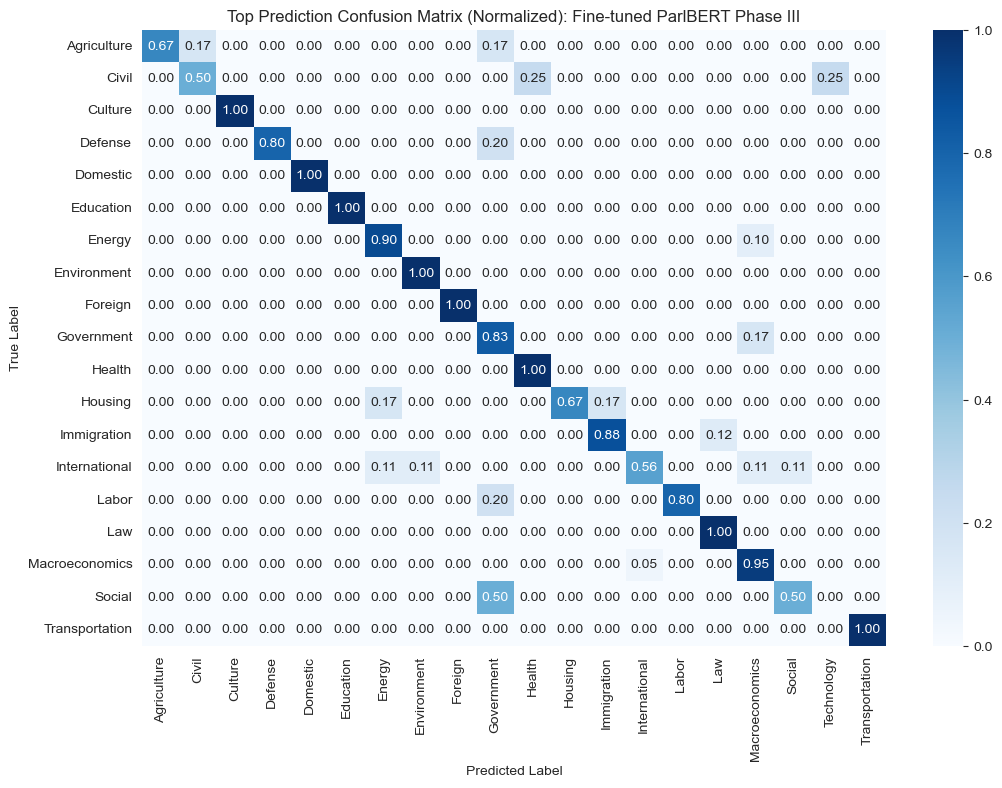

In [9]:
confusion_top = pd.crosstab(
    gold_label,
    prediction_phaseIII,
    rownames=['True Label'],
    colnames=['Predicted Label'],
    normalize='index'
)

plt.figure(figsize=(12,8))
sns.heatmap(confusion_top, annot=True, fmt=".2f", cmap="Blues")
plt.title("Top Prediction Confusion Matrix (Normalized): Fine-tuned ParlBERT Phase III")
plt.show()

In [10]:
print(classification_report(gold_label, prediction_phaseIII))

                precision    recall  f1-score   support

   Agriculture       1.00      0.67      0.80         6
         Civil       0.67      0.50      0.57         4
       Culture       1.00      1.00      1.00         1
       Defense       1.00      0.80      0.89         5
      Domestic       1.00      1.00      1.00         1
     Education       1.00      1.00      1.00         1
        Energy       0.82      0.90      0.86        10
   Environment       0.67      1.00      0.80         2
       Foreign       1.00      1.00      1.00         2
    Government       0.56      0.83      0.67         6
        Health       0.75      1.00      0.86         3
       Housing       1.00      0.67      0.80         6
   Immigration       0.88      0.88      0.88         8
 International       0.83      0.56      0.67         9
         Labor       1.00      0.80      0.89         5
           Law       0.88      1.00      0.93         7
Macroeconomics       0.86      0.95      0.90  

C:\Users\hanna\miniconda3\envs\im2024\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hanna\miniconda3\envs\im2024\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hanna\miniconda3\envs\im2024\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# social, only 2 cases, one not enough context , had to look at more context than two previous sentence, agenda item, something we had to do twice out of 100 times, rarely happens
# ansonsten hier: vereine zwar sonst social, aber hier im internationalen kontext
# Nun zu den juristischen Einwänden, die im Antrag der Union formuliert werden. Die Ziele dieser Richtlinie, nämlich die Gleichbehandlung von Vereinen im Binnenmarkt sicherzustellen und die regulatorischen Formalitäten von grenzübergreifenden Vereinen zu vereinfachen und zu vereinheitlichen, diese Ziele liegen sehr wohl in der Kompetenz der EU.
# civil provlematic class:
#  # nur wegen frauen, stattdessen agriculture
# sonst einmal overlap mit health (verschwörungstheorie mit covid) und technology (freie wissenschaft)
# international problematic class:
# statt international öfter mal spezifisches policy topic, manchmal unintuitiv (wie mit verein gesehen, aber auch environment ansätze in china,
# einmal macroeconomics statt international predicted, afd gegen euro, aber eigentlich gegen gesamte EU
# international overpredicted: Vielleicht ist es notwendig, noch mal an die Rahmenbedingungen zu erinnern. Wir befinden uns jetzt seit fast vier Jahren im Dauerkrisenmodus: erst Corona, dann der russische Angriffskrieg gegen die Ukraine. -> angriffskrieg nur als kontext für hohe ausgaben

# housing problematic:
# gebäudeenergiegesetz erwähnt, aber wechsel zum thema wohnungsnot
# ein zuhause, egal wo jemand herkommt (implied immigration, afd beschwer über zu hohe mitepreise wegen angeblich einwanderern, versuchtes framing), aber
# antwort auf wohnungspolitik allgemein umgewältzt